# RSNA Pneumonia — Notebook 2 : Inférence YOLO26x → MedGemma 1.5 4B

Chaîne d'inférence image par image :
1. **YOLO26x** prédit les boxes d'opacité (seuil de confiance **0.25**).
2. On calcule une **localisation lisible** par box (poumon droit/gauche du patient, plage haute/moyenne/basse).
3. **MedGemma 1.5 4B** (4-bit) reçoit l'image + les détections et rédige une description clinique
   courte (1-3 phrases), **ancrée sur les boxes**, sans réinventer de findings.

Sortie par image : classe (pneumonie oui/non) · boxes · description.

In [ ]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "1"

In [2]:
# --- Installations ---
!pip install -q -U ultralytics transformers accelerate bitsandbytes hf_transfer
!pip install -q pydicom
!pip install -q --force-reinstall --no-deps "pillow==11.3.0"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 20.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 96.6 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 32.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 94.2 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 54.6 MB/s eta 0:00:0000:0100:01


In [18]:
import glob, random
from pathlib import Path
import numpy as np
import cv2, pydicom
import torch
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from transformers import AutoProcessor, AutoModelForImageTextToText, BitsAndBytesConfig
from huggingface_hub import login

print("CUDA :", torch.cuda.is_available(), "| GPU visible :", os.environ.get("CUDA_VISIBLE_DEVICES"))

# --- Paramètres ---
MEDGEMMA_ID = "google/medgemma-1.5-4b-it"
IMGSZ       = 640
CONF_THRES  = 0.25
SHRINK      = 0.85
NMS_IOU     = 0.4
CLAHE_CLIP, CLAHE_GRID = 2.0, (8, 8)

# Poids YOLO entraînés au notebook 1.
# Adapte ce chemin : dataset/Kaggle-model attaché, ou dossier runs si même session.
YOLO_WEIGHTS = "/kaggle/input/datasets/jeankevin56/rsna-yolo26m-best/best.pt"
if not os.path.exists(YOLO_WEIGHTS):
    YOLO_WEIGHTS = "/kaggle/working/runs/yolo26x_rsna/weights/best.pt"
print("YOLO weights :", YOLO_WEIGHTS)
BASE_DIR = "/kaggle/input/competitions/rsna-pneumonia-detection-challenge"
LABELS_CSV = "/kaggle/input/competitions/rsna-pneumonia-detection-challenge/stage_2_train_labels.csv"
TRAIN_DCM = "/kaggle/input/competitions/rsna-pneumonia-detection-challenge/stage_2_train_images"

CUDA : True | GPU visible : 0
YOLO weights : /kaggle/input/datasets/jeankevin56/rsna-yolo26m-best/best.pt


In [13]:
from kaggle_secrets import UserSecretsClient
HF_TOKEN = UserSecretsClient().get_secret("HF_TOKEN")   # secret Kaggle nommé HF_TOKEN
login(token=HF_TOKEN)
print("Connecté à Hugging Face.")

Connecté à Hugging Face.


In [14]:
from ultralytics import YOLO
yolo = YOLO(YOLO_WEIGHTS)
print("YOLO26x chargé.")

YOLO26x chargé.


In [15]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,     # T4 -> float16
    bnb_4bit_use_double_quant=True,
)
processor = AutoProcessor.from_pretrained(MEDGEMMA_ID, token=HF_TOKEN)
model = AutoModelForImageTextToText.from_pretrained(
    MEDGEMMA_ID,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.float16,
    attn_implementation="eager",   # Gemma3 : évite des sorties vides avec SDPA + 4-bit
    token=HF_TOKEN,
)
model.eval()
print("MedGemma 1.5 4B chargé en 4-bit.")

Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

MedGemma 1.5 4B chargé en 4-bit.


In [19]:
import pandas as pd
# --- Vérité terrain (boxes réelles du dataset), mise à l'échelle IMGSZ ---
labels = pd.read_csv(LABELS_CSV)
_pos = labels[labels.Target == 1]
GT = {pid: g[["x", "y", "width", "height"]].values.tolist()
      for pid, g in _pos.groupby("patientId")}

def gt_boxes(patient_id):
    S = IMGSZ / 1024.0                     # les boxes du CSV sont en pixels sur 1024
    return [(x*S, y*S, w*S, h*S) for (x, y, w, h) in GT.get(patient_id, [])]

print(f"Patients avec pneumonie (vérité terrain) : {len(GT)}")

Patients avec pneumonie (vérité terrain) : 6012


### Si un gros fichier se fige au téléchargement
Télécharge d'abord le snapshot, puis charge en local :
```python
from huggingface_hub import snapshot_download
local = snapshot_download(MEDGEMMA_ID, token=HF_TOKEN)
processor = AutoProcessor.from_pretrained(local, local_files_only=True)
model = AutoModelForImageTextToText.from_pretrained(
    local, quantization_config=bnb_config, device_map="auto",
    torch_dtype=torch.float16, local_files_only=True)
```

In [21]:
def dicom_to_rgb(dcm_path, size=IMGSZ):
    dcm = pydicom.dcmread(dcm_path)
    img = dcm.pixel_array.astype(np.float32)
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    img = (img * 255.0).astype(np.uint8)
    if img.shape[0] != size:
        img = cv2.resize(img, (size, size), interpolation=cv2.INTER_AREA)
    clahe = cv2.createCLAHE(clipLimit=CLAHE_CLIP, tileGridSize=CLAHE_GRID)
    return cv2.cvtColor(clahe.apply(img), cv2.COLOR_GRAY2RGB)

def shrink_box(x1, y1, x2, y2, s):
    cx, cy = (x1+x2)/2, (y1+y2)/2
    w, h = (x2-x1)*s, (y2-y1)*s
    return cx-w/2, cy-h/2, cx+w/2, cy+h/2

def localize(cx, cy, img_size=IMGSZ):
    side = "right lung (patient)" if cx < img_size/2 else "left lung (patient)"
    t = cy / img_size
    zone = "upper zone" if t < 1/3 else ("mid zone" if t < 2/3 else "lower zone")
    return f"{side}, {zone}"

def predict_boxes(rgb):
    # renvoie [(x1,y1,x2,y2,conf), ...] après rétrécissement
    res = yolo.predict(rgb, conf=CONF_THRES, iou=NMS_IOU, imgsz=IMGSZ, verbose=False)[0]
    out = []
    for b in res.boxes:
        x1, y1, x2, y2 = b.xyxy[0].tolist()
        x1, y1, x2, y2 = shrink_box(x1, y1, x2, y2, SHRINK)
        out.append((x1, y1, x2, y2, float(b.conf[0])))
    return out

In [22]:
SYSTEM_PROMPT = (
    "You are a radiology assistant. You are given a frontal chest X-ray and a list of "
    "pneumonia-suspicious regions already detected by an object detector. "
    "Write a concise clinical description (1-3 sentences) STRICTLY grounded in the provided "
    "detections. Do not invent findings that are not in the list. If the list is empty, "
    "state that no focal opacity was detected. Use standard radiological laterality "
    "(the patient's right lung appears on the left of the image)."
)

@torch.inference_mode()
def describe(pil_img, detections):
    if detections:
        lines = [
            f"- region {i+1}: {localize((d[0]+d[2])/2, (d[1]+d[3])/2)}, "
            f"confidence {d[4]:.2f}, box(x={d[0]:.0f}, y={d[1]:.0f}, "
            f"w={d[2]-d[0]:.0f}, h={d[3]-d[1]:.0f})"
            for i, d in enumerate(detections)
        ]
        det_txt = "Detected regions:\n" + "\n".join(lines)
    else:
        det_txt = "Detected regions: none."

    messages = [
        {"role": "system", "content": [{"type": "text", "text": SYSTEM_PROMPT}]},
        {"role": "user", "content": [
            {"type": "image", "image": pil_img},
            {"type": "text", "text": det_txt + "\n\nWrite the clinical description now."},
        ]},
    ]
    inputs = processor.apply_chat_template(
        messages, add_generation_prompt=True, tokenize=True,
        return_dict=True, return_tensors="pt",
    ).to(model.device, dtype=torch.float16)

    input_len = inputs["input_ids"].shape[-1]
    gen = model.generate(**inputs, max_new_tokens=800, do_sample=False)
    return processor.decode(gen[0][input_len:], skip_special_tokens=True).strip()

In [23]:
test_pid = next(iter(GT))
rgb = dicom_to_rgb(os.path.join(TRAIN_DCM, test_pid + ".dcm"))
dets = predict_boxes(rgb)
out = describe(Image.fromarray(rgb), dets)
print("boxes YOLO :", len(dets))
print("description :", repr(out))

boxes YOLO : 2
description : ''


In [25]:
def analyze(patient_id):
    rgb = dicom_to_rgb(os.path.join(TRAIN_DCM, patient_id + ".dcm"))
    dets = predict_boxes(rgb)
    return {
        "pneumonia": len(dets) > 0,
        "pred": dets,                       # (x1,y1,x2,y2,conf)
        "gt": gt_boxes(patient_id),         # (x,y,w,h)
        "description": describe(Image.fromarray(rgb), dets),
        "image": rgb,
    }


In [26]:
def show_result(result, title=""):
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.imshow(result["image"]); ax.axis("off")
    for (x, y, w, h) in result["gt"]:                       # réel = vert
        ax.add_patch(patches.Rectangle((x, y), w, h, fill=False, edgecolor="lime", lw=2))
    for (x1, y1, x2, y2, c) in result["pred"]:              # prédit = rouge
        ax.add_patch(patches.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, edgecolor="red", lw=2))
        ax.text(x1, y1-4, f"{c:.2f}", color="red", fontsize=8,
                bbox=dict(facecolor="white", alpha=0.6, pad=1))
    verdict = "PNEUMONIE" if result["pneumonia"] else "aucune box"
    ax.set_title(f"{title}  [vert=réel · rouge=prédit · {verdict}]", fontsize=10)
    plt.tight_layout(); plt.show()
    print("Description MedGemma :", result["description"])
    print("-" * 80)

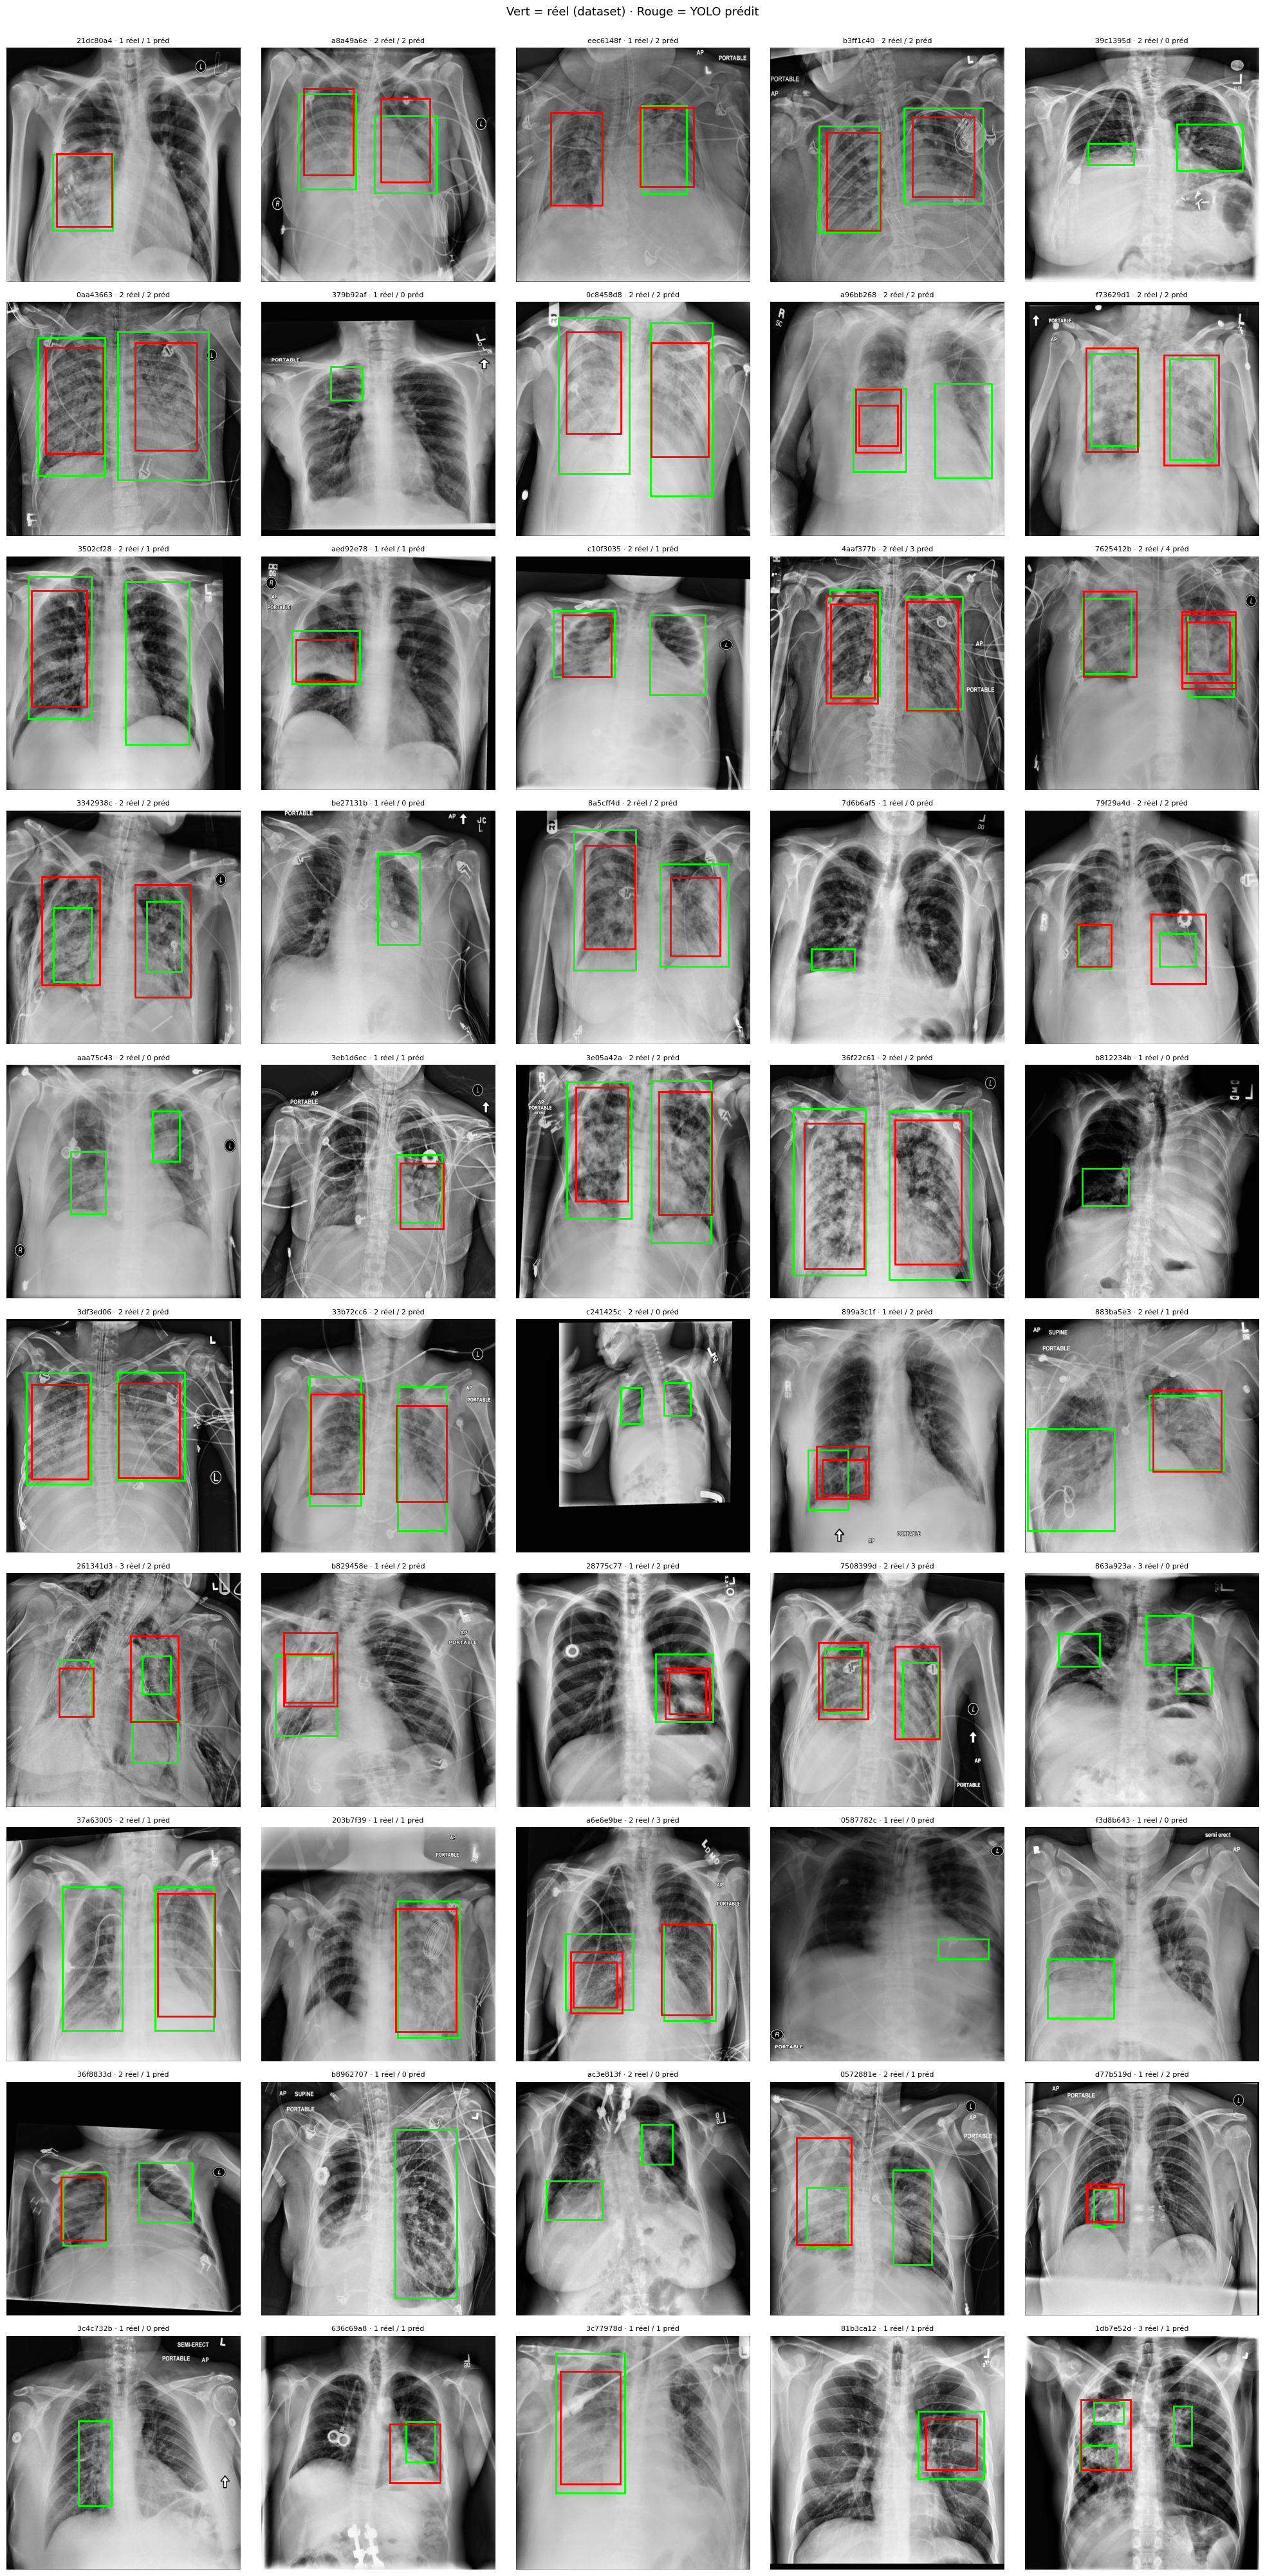

In [29]:
N_SHOW = 50          # nombre d'images à afficher
COLS   = 5

pos_ids = list(GT.keys())
random.seed(1); random.shuffle(pos_ids)
sample = pos_ids[:N_SHOW]

rows = (N_SHOW + COLS - 1) // COLS
fig, axes = plt.subplots(rows, COLS, figsize=(4*COLS, 4*rows))
for ax, pid in zip(axes.ravel(), sample):
    rgb = dicom_to_rgb(os.path.join(TRAIN_DCM, pid + ".dcm"))
    ax.imshow(rgb); ax.axis("off")
    for (x, y, w, h) in gt_boxes(pid):                      # réel
        ax.add_patch(patches.Rectangle((x, y), w, h, fill=False, edgecolor="lime", lw=2))
    n_pred = 0
    for (x1, y1, x2, y2, c) in predict_boxes(rgb):          # prédit
        ax.add_patch(patches.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, edgecolor="red", lw=2))
        n_pred += 1
    ax.set_title(f"{pid[:8]} · {len(gt_boxes(pid))} réel / {n_pred} préd", fontsize=8)
for ax in axes.ravel()[len(sample):]:
    ax.axis("off")
plt.suptitle("Vert = réel (dataset) · Rouge = YOLO prédit", y=1.0, fontsize=13)
plt.tight_layout(); plt.show()

### Format de sortie par image
`analyze()` renvoie un dict :
- `pneumonia` : booléen (au moins une box détectée)
- `detections` : liste `{conf, box=(x,y,w,h), loc}`
- `description` : texte clinique MedGemma (1-3 phrases, ancré sur les détections)

Le prompt MedGemma est en anglais (meilleure qualité clinique du modèle). Pour une sortie en
français, traduis `description` ou adapte `SYSTEM_PROMPT`.